# Clusterização — Segmentação de Clientes de um Shopping

**Disciplina:** Machine Learning — Técnicas Especiais de Análise de Dados
**Aluno:** Eduardo Vitor Oliveira
**Professor:** Ricardo
**Data:** 18/09/2026
**Dataset:** [Mall Customer Segmentation Data](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python) — Kaggle

### Objetivo
A partir de dados de idade, renda anual e pontuação de gastos de clientes de um shopping, o objetivo é **agrupar os clientes por similaridade** (aprendizado não supervisionado) para compreender diferentes perfis de consumo e apoiar estratégias de marketing segmentado (ex.: campanhas específicas para clientes de alta renda e baixo gasto, ou de baixa renda e alto gasto).

O algoritmo utilizado é o **K-Means**, que particiona os dados em K grupos (clusters) minimizando a distância dos pontos até o centro do seu grupo. Como o valor de K não é conhecido a priori, usamos duas técnicas para escolhê-lo:

- **Método do Cotovelo (Elbow Method)** — observa a queda da inércia (soma dos quadrados intra-cluster) conforme K aumenta;
- **Silhouette Score** — mede o quão bem separados e coesos estão os clusters (varia de -1 a 1; quanto mais próximo de 1, melhor).


## 1. Obtenção do dataset

In [ ]:
!pip install -q kaggle
from google.colab import files
print("Selecione o arquivo kaggle.json baixado da sua conta Kaggle:")
uploaded = files.upload()


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d vjchoudhary7/customer-segmentation-tutorial-in-python -p ./dados --unzip
!ls ./dados


> **Alternativa sem API do Kaggle:** baixe `Mall_Customers.csv` manualmente do link do dataset e faça upload com `files.upload()`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('./dados/Mall_Customers.csv')
df.head(10)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


## 2. Conhecendo o dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
# Padronizando o nome da coluna de gênero, que em algumas versões do dataset vem como "Genre" (erro de digitação original)
df = df.rename(columns={"Genre": "Gender"})
df['Gender'].value_counts()


Gender
Female    112
Male       88
Name: count, dtype: int64

## 3. Análise exploratória

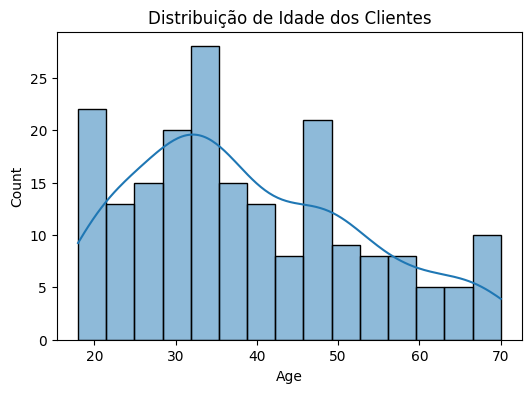

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=15, kde=True)
plt.title('Distribuição de Idade dos Clientes')
plt.show()


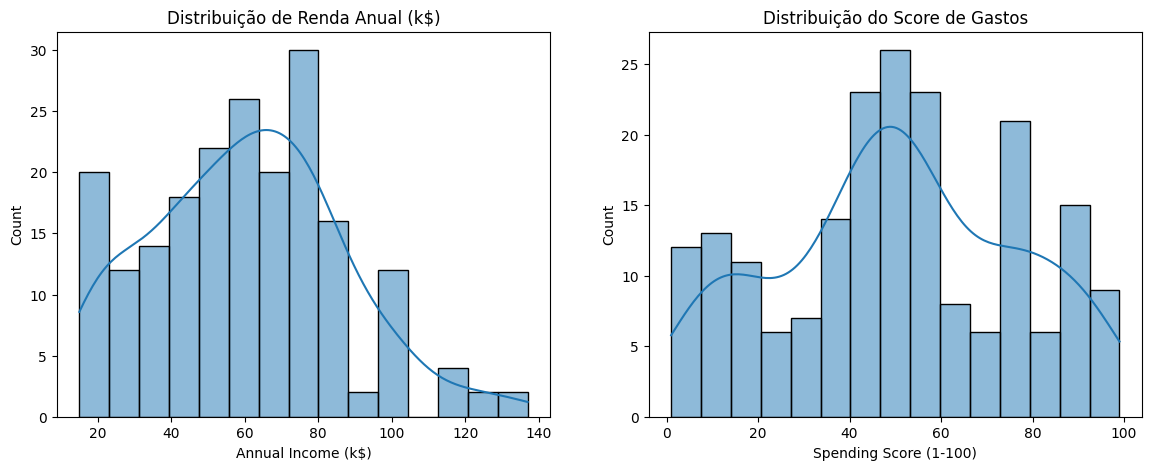

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(df['Annual Income (k$)'], bins=15, kde=True, ax=axes[0])
axes[0].set_title('Distribuição de Renda Anual (k$)')
sns.histplot(df['Spending Score (1-100)'], bins=15, kde=True, ax=axes[1])
axes[1].set_title('Distribuição do Score de Gastos')
plt.show()


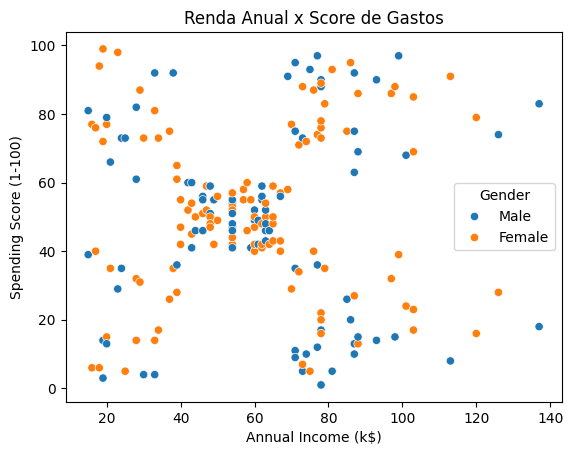

In [9]:
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender')
plt.title('Renda Anual x Score de Gastos')
plt.show()


## 4. Pré-processamento: seleção e normalização das variáveis

Usaremos as três variáveis numéricas mais relevantes para o comportamento de consumo: **Idade**, **Renda Anual** e **Score de Gastos**. Como estão em escalas diferentes, normalizamos com `MinMaxScaler` antes de aplicar o K-Means (o algoritmo é sensível à escala das variáveis, já que se baseia em distância euclidiana).

In [10]:
variaveis = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

normalizador = MinMaxScaler()
variaveis_norm = normalizador.fit_transform(variaveis)
variaveis_norm[:5]


array([[0.01923077, 0.        , 0.3877551 ],
       [0.05769231, 0.        , 0.81632653],
       [0.03846154, 0.00819672, 0.05102041],
       [0.09615385, 0.00819672, 0.7755102 ],
       [0.25      , 0.01639344, 0.39795918]])

## 5. Determinando o número ideal de clusters (K)

In [11]:
k_range = range(2, 11)
inercias = []
silhuetas = []

for k in k_range:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = modelo.fit_predict(variaveis_norm)
    inercias.append(modelo.inertia_)
    silhuetas.append(silhouette_score(variaveis_norm, labels))


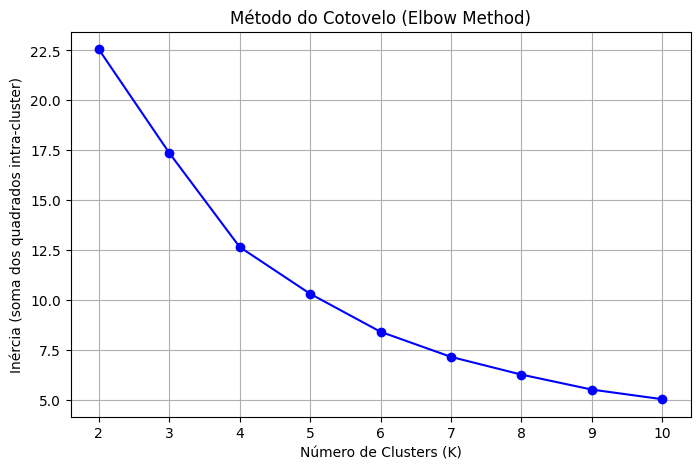

In [12]:
plt.figure(figsize=(8,5))
plt.plot(list(k_range), inercias, 'bo-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (soma dos quadrados intra-cluster)')
plt.title('Método do Cotovelo (Elbow Method)')
plt.grid(True)
plt.show()


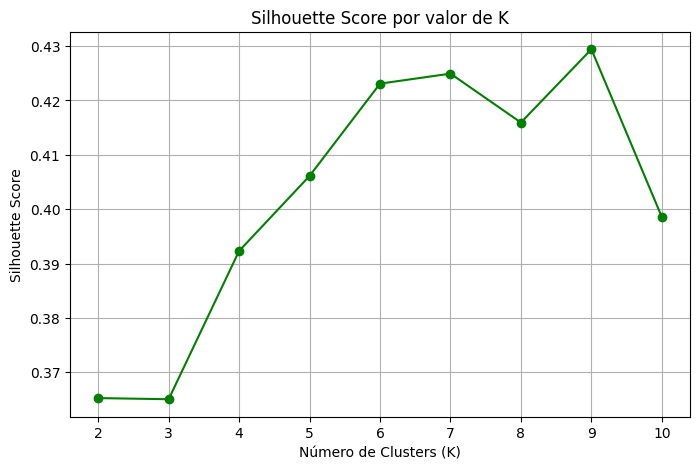

Melhor K pelo Silhouette Score: 9


In [13]:
plt.figure(figsize=(8,5))
plt.plot(list(k_range), silhuetas, 'go-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por valor de K')
plt.grid(True)
plt.show()

melhor_k = list(k_range)[int(np.argmax(silhuetas))]
print(f"Melhor K pelo Silhouette Score: {melhor_k}")


## 6. Treinando o modelo final de K-Means

In [14]:
modelo_final = KMeans(n_clusters=melhor_k, random_state=42, n_init=10)
df['cluster'] = modelo_final.fit_predict(variaveis_norm)

print("Silhouette Score final:", silhouette_score(variaveis_norm, df['cluster']))
df.head()


Silhouette Score final: 0.4294226583863391


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,5
2,3,Female,20,16,6,3
3,4,Female,23,16,77,5
4,5,Female,31,17,40,3


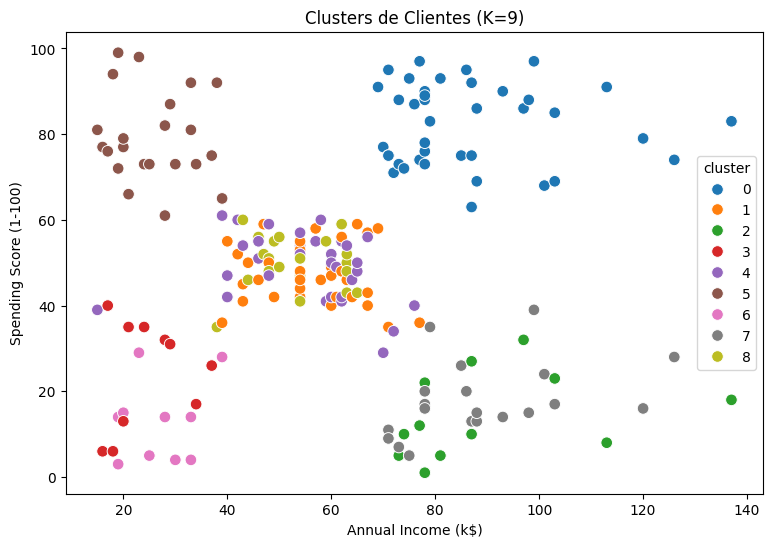

In [15]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                 hue='cluster', palette='tab10', s=70)
plt.title(f'Clusters de Clientes (K={melhor_k})')
plt.show()


## 7. Perfil de cada cluster

Aqui interpretamos o que cada grupo representa em termos de negócio — essa é a parte que gera valor prático para o time de marketing.

In [16]:
perfil_clusters = df.groupby('cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
perfil_clusters['quantidade_clientes'] = df.groupby('cluster').size()
perfil_clusters


,Age,Annual Income (k$),Spending Score (1-100),quantidade_clientes
cluster,,,,
0,32.692308,86.538462,82.128205,39
1,47.121212,56.212121,47.454545,33
2,30.461538,89.461538,13.384615,13
3,35.600000,24.400000,24.100000,10
4,24.575758,54.545455,49.181818,33
5,25.272727,25.727273,79.363636,22
6,55.200000,26.900000,13.000000,10
7,48.600000,88.850000,18.000000,20
8,64.850000,53.150000,49.850000,20


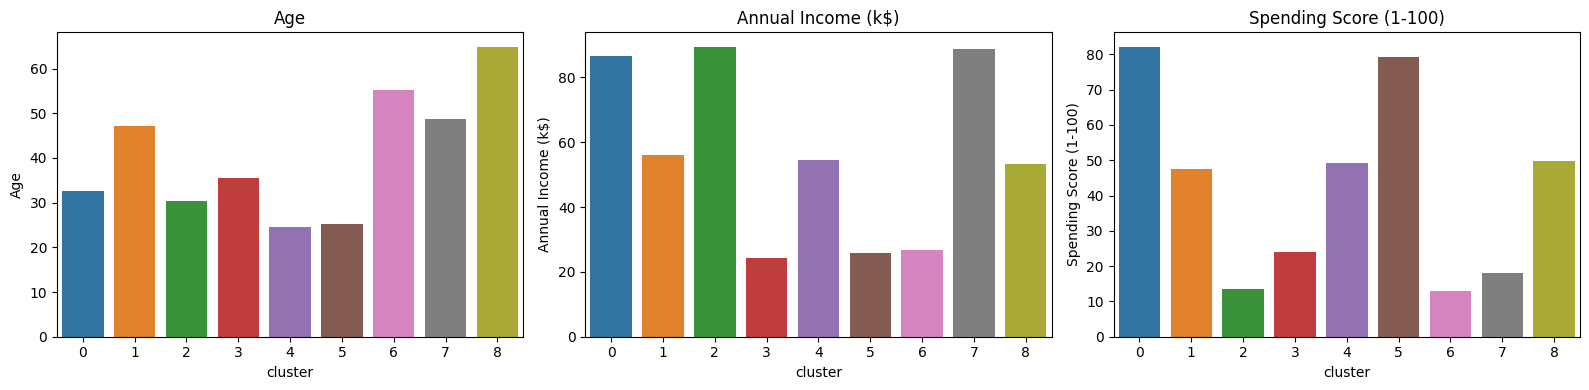

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
for ax, col in zip(axes, ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']):
    sns.barplot(x=perfil_clusters.index, y=perfil_clusters[col], ax=ax, palette='tab10')
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 8. Conclusões

Com os **200 clientes** do dataset, o Silhouette Score apontou **K=9** como o número ideal de clusters (score de 0,429 — indica clusters razoavelmente bem separados, sem sobreposição forte). O perfil de cada grupo revela segmentos de consumo bem diferentes:

| Cluster | Idade média | Renda anual média | Score de gastos médio | Nº de clientes | Perfil sugerido |
|---|---|---|---|---|---|
| 0 | 32,7 | 86,5 k$ | 82,1 | 39 | **Alta renda, alto gasto** — cliente premium, prioridade máxima em campanhas de produtos de maior ticket |
| 2 | 30,5 | 89,5 k$ | 13,4 | 13 | **Alta renda, baixo gasto** — engajamento baixo apesar do poder de compra; oportunidade de campanhas de reativação |
| 7 | 48,6 | 88,9 k$ | 18,0 | 20 | Similar ao cluster 2, mas com público mais velho — mesma estratégia de reativação, tom de comunicação diferente |
| 5 | 25,3 | 25,7 k$ | 79,4 | 22 | **Baixa renda, alto gasto** — sensível a promoções e parcelamento, público jovem |
| 3 e 6 | 35,6 e 55,2 | ~25 k$ | ~13-24 | 10 e 10 | **Baixa renda, baixo gasto** — menor prioridade em investimento de marketing |
| 1, 4 e 8 | 47,1 / 24,6 / 64,9 | ~53-56 k$ | ~47-50 | 33 / 33 / 20 | Perfil intermediário em renda e gasto — bom público para ofertas de fidelização, diferenciando por faixa etária |

**Principal insight de negócio:** os clusters 0 e 2 mostram claramente que "alta renda" não significa automaticamente "alto gasto na loja" — há um grupo grande (33 clientes, clusters 2+7) de clientes com poder aquisitivo alto mas engajamento baixo, que representa a maior oportunidade de crescimento de receita via campanhas direcionadas.
